In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [44]:
order_items = pd.read_csv(r'C:\Users\Karwi\OneDrive\Desktop\ecommerce_project_dataset_bundle\CSV Files\Orders_and_items_table.csv')

In [45]:
order_items.head()

,order_item_id,order_id,order_date,customer_id,customer_region,product_category,quantity_sold,discount_percent,line_revenue,payment_method
0,1,1,2024-01-08,1488,Africa,Fashion,1,30,74.69,UPI
1,2,1,2024-01-08,1488,Africa,Home & Kitchen,1,10,170.40,UPI
2,3,1,2024-01-08,1488,Africa,Electronics,4,0,326.80,UPI
3,4,2,2023-10-04,1078,South America,Sports,2,25,109.76,Apple Pay
4,5,3,2022-03-08,1853,Europe,Fashion,4,25,105.44,Debit Card


In [46]:
order_items.isnull().sum()

order_item_id       0
order_id            0
order_date          0
customer_id         0
customer_region     0
product_category    0
quantity_sold       0
discount_percent    0
line_revenue        0
payment_method      0
dtype: int64

In [47]:
order_items[['quantity_sold', 'discount_percent', 'line_revenue']].describe().round(2)

,quantity_sold,discount_percent,line_revenue
count,8534.00,8534.00,8534.00
mean,1.93,12.19,335.45
std,1.11,8.46,483.23
min,1.00,0.00,5.52
25%,1.00,5.00,69.45
50%,2.00,10.00,157.28
75%,3.00,20.00,395.42
max,5.00,30.00,4362.25


In [48]:
order_items.info(
)

<class 'pandas.DataFrame'>
RangeIndex: 8534 entries, 0 to 8533
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_item_id     8534 non-null   int64  
 1   order_id          8534 non-null   int64  
 2   order_date        8534 non-null   str    
 3   customer_id       8534 non-null   int64  
 4   customer_region   8534 non-null   str    
 5   product_category  8534 non-null   str    
 6   quantity_sold     8534 non-null   int64  
 7   discount_percent  8534 non-null   int64  
 8   line_revenue      8534 non-null   float64
 9   payment_method    8534 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 666.8 KB


In [49]:
order_items.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8529    False
8530    False
8531    False
8532    False
8533    False
Length: 8534, dtype: bool

In [50]:
#Format order_date column to be datetime
order_items['order_date']= pd.to_datetime(order_items['order_date'])

In [51]:
#Create a year column based on order_date column
order_items['year']= order_items['order_date'].dt.to_period('Y')


In [52]:
order_items.head()

,order_item_id,order_id,order_date,customer_id,customer_region,product_category,quantity_sold,discount_percent,line_revenue,payment_method,year
0,1,1,2024-01-08,1488,Africa,Fashion,1,30,74.69,UPI,2024
1,2,1,2024-01-08,1488,Africa,Home & Kitchen,1,10,170.40,UPI,2024
2,3,1,2024-01-08,1488,Africa,Electronics,4,0,326.80,UPI,2024
3,4,2,2023-10-04,1078,South America,Sports,2,25,109.76,Apple Pay,2023
4,5,3,2022-03-08,1853,Europe,Fashion,4,25,105.44,Debit Card,2022


In [53]:
order_items.groupby('year')['line_revenue'].sum().round(2).reset_index().sort_values('line_revenue', ascending=False).head(10)

,year,line_revenue
0,2022,1020527.04
2,2024,929177.38
1,2023,913049.99


# Which regions and categories drive the most revenue?

In [54]:
# Total revenue by region

total_by_region= order_items.groupby('customer_region')['line_revenue'].sum().round(2).reset_index().sort_values('line_revenue', ascending=True).head(5)

total_by_region.head()

,customer_region,line_revenue
2,Europe,396050.59
0,Africa,438368.70
5,South America,442784.10
1,Asia,524815.83
3,Middle East,529334.54


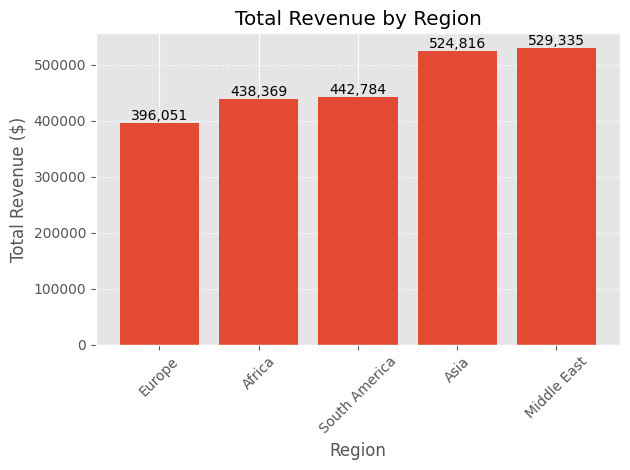

In [55]:
plt.bar(total_by_region['customer_region'], total_by_region['line_revenue'])
plt.title('Total Revenue by Region')
for i, v in enumerate(total_by_region['line_revenue']):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.Figure(figsize=(8,5))
plt.grid(axis='y', linestyle='--', alpha=0.7);

The North American region leads the overall combined revenue from 2022 to 2024 in comparison to the rest of the regions. 

In [56]:
# Top region per year

year_region = order_items.groupby(['year','customer_region' ])['line_revenue'].sum().round(2).reset_index().sort_values('line_revenue', ascending=False).head(5)

top_per_year = year_region.loc[
    year_region.groupby('year')['line_revenue'].idxmax()
]

top_per_year.head()

,year,customer_region,line_revenue
1,2022,Asia,208964.84
9,2023,Middle East,177940.38
15,2024,Middle East,183356.40



### Insight: 

While North America generatest he most revenue across all years, regional leaderiship shifts overtime, with Asia leading in 2022 and Middle East positioning as the top performer in 2023 and 2024

In [57]:
# Total revenue by categories

total_revenue_category = order_items.groupby('product_category')['line_revenue'].sum().round(2).reset_index().sort_values('line_revenue', ascending=True)

total_revenue_category.head()

,product_category,line_revenue
1,Books,55484.46
0,Beauty,177648.39
3,Fashion,226569.95
5,Sports,340464.43
4,Home & Kitchen,463223.94


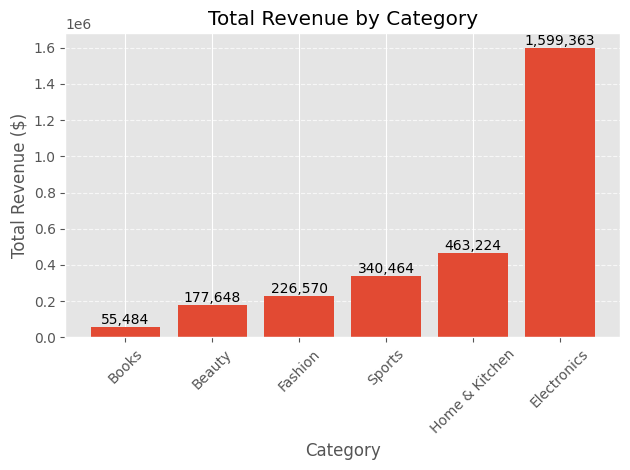

In [58]:
plt.bar(total_revenue_category['product_category'], total_revenue_category['line_revenue'])
plt.title('Total Revenue by Category')
for i, v in enumerate(total_revenue_category['line_revenue']):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.Figure(figsize=(8,5))
plt.grid(axis='y', linestyle='--', alpha=0.7);

### Insight

Electronics lead the overall revenue by category, contributing significantly more than any other category with revenue more than three times higher than the next leading category (Home & Kitchen). This suggests that electronics are a major driver of overall business performance, potentially due to higher pricing or larger order values. 

# Category Performance by Region

In [59]:
product_per_region = order_items.groupby(['customer_region', 'product_category'])['line_revenue'].sum().round(2).reset_index().sort_values('line_revenue', ascending=False)

product_per_region.head(5)

,customer_region,product_category,line_revenue
20,Middle East,Electronics,315143.70
8,Asia,Electronics,308123.15
26,North America,Electronics,303481.74
2,Africa,Electronics,229317.40
32,South America,Electronics,227302.81


### Insight

The electronics category is the primay driver of global revenue, signficantly outperforming all product categories. Home & Kitchen ranks second, though with substantial gap compared to Electronics.

In [60]:
top_per_region = product_per_region.loc[product_per_region.groupby('customer_region')['line_revenue'].idxmax()]

top_per_region.head(5)

,customer_region,product_category,line_revenue
2,Africa,Electronics,229317.40
8,Asia,Electronics,308123.15
14,Europe,Electronics,215994.44
20,Middle East,Electronics,315143.70
26,North America,Electronics,303481.74


### Insight

The consistent dominance of Electronics suggests that the demand for electronic products is strong indicating globally uniform driver rather than region-specific category reference. 

## What products or categories benefit most from discounts?

In [61]:
# Discount levels and frequency
order_items['discount_percent'].value_counts().reset_index()

,discount_percent,count
0,10,1738
1,15,1620
2,5,1424
3,0,1353
4,20,1321
5,25,702
6,30,376


In [62]:
#Discount levels vs total revenue
discount_vs_total = order_items.groupby('discount_percent')['line_revenue'].sum().reset_index().sort_values('line_revenue', ascending=True)

discount_vs_total.rename(columns={'line_revenue': 'total_revenue'}, inplace=True)

discount_vs_total.head(7)

,discount_percent,total_revenue
6,30,100350.95
5,25,200749.54
0,0,407593.05
1,5,449684.74
4,20,484892.94
3,15,571856.84
2,10,647626.35


''

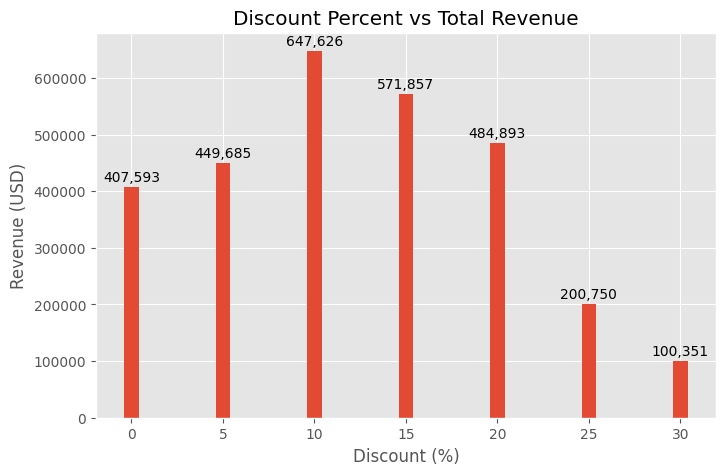

In [ ]:
# Viz: Discount percent vs Total revenue
plt.figure(figsize=(8,5))
plt.bar(discount_vs_total['discount_percent'], discount_vs_total['total_revenue'])
plt.title('Discount Percent vs Total Revenue')
plt.xlabel('Discount (%)')
plt.ylabel('Revenue (USD)')
for i, v in zip(discount_vs_total['discount_percent'], discount_vs_total['total_revenue']):
    plt.text(i,v +5000, f'{v:,.0f}', ha='center', va='bottom');


### Insight

The first table, discount vs frequency, describes that there are 7 different discount levels. Out of all the levels, the 10% discount suggest to have the most frequency. On the other hand, the 30% discount suggests to have the least frequency among all 7 levels. This insight is reflected on the second table suggesting that the 10% discount generates more revenue than the rest of the levels. Although, this insight suggests the 10% discount performs better than the other leves, this is based on total revenue and not on performance per transaction. Further analysis will help understand discount percentages perform per transaction. 

## Do higher discounts actually perform better per transactions?

In [64]:
discount_vs_average = order_items.groupby('discount_percent')['line_revenue'].mean().reset_index().round(2).sort_values('line_revenue', ascending=False)

discount_vs_average.rename(columns={'line_revenue': 'avg_revenue'}, inplace=True)

discount_vs_average.head(7)

,discount_percent,avg_revenue
2,10,372.63
4,20,367.07
3,15,353.00
1,5,315.79
0,0,301.25
5,25,285.97
6,30,266.89


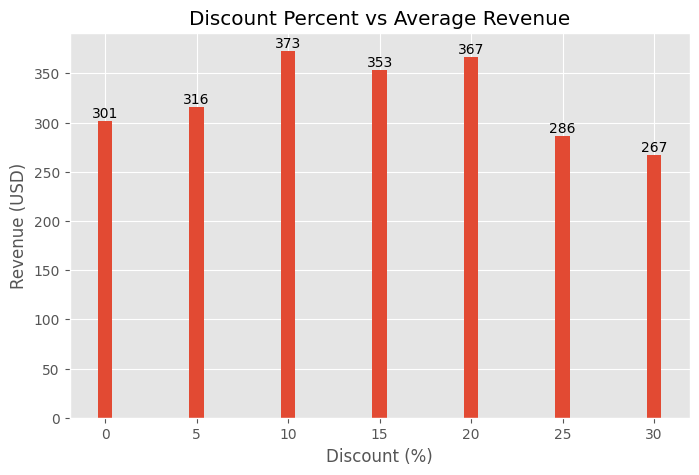

In [65]:
plt.figure(figsize=(8,5))
plt.bar(discount_vs_average['discount_percent'], discount_vs_average['avg_revenue'])
plt.title('Discount Percent vs Average Revenue')
plt.xlabel('Discount (%)')
plt.ylabel('Revenue (USD)')
for i, v in zip(discount_vs_average['discount_percent'], discount_vs_average['avg_revenue']):
    plt.text(i,v + .5, f'{v:,.0f}', ha='center', va='bottom');

### Insight
The 10% discount level is optimal, as it not only generates the highest total revenue but also delivers the strongest average performance per transaction, while higher discounts reduce both efficiency and returns.

## Circling back to the main question: What product or category benefits most from discounts?

In [66]:
discount_vs_category = order_items.groupby(['discount_percent', 'product_category'])['line_revenue'].mean().reset_index().round(2)

discount_vs_category.head(53)

,discount_percent,product_category,line_revenue
0,0,Beauty,149.63
1,0,Books,51.86
2,0,Electronics,943.40
3,0,Fashion,174.74
4,0,Home & Kitchen,373.71
5,0,Sports,251.69
6,5,Beauty,133.50
7,5,Books,53.34
8,5,Electronics,1055.99
9,5,Fashion,154.22


In [67]:
order_items[order_items['product_category'] == 'Electronics'].groupby('discount_percent')['line_revenue'].mean().reset_index().round(2)

,discount_percent,line_revenue
0,0,943.40
1,5,1055.99
2,10,1073.15
3,15,942.55
4,20,909.92
5,25,742.64
6,30,601.29


In [68]:
for category in order_items['product_category'].unique():
    subset = order_items[order_items['product_category'] == category]
    grouped = subset.groupby(['discount_percent', 'product_category'])['line_revenue'].mean().reset_index().round(2)
    print(category)
    print(grouped)

Fashion
   discount_percent product_category  line_revenue
0                 0          Fashion        174.74
1                 5          Fashion        154.22
2                10          Fashion        152.02
3                15          Fashion        145.10
4                20          Fashion        131.10
5                25          Fashion        127.53
6                30          Fashion        123.39
Home & Kitchen
   discount_percent product_category  line_revenue
0                 0   Home & Kitchen        373.71
1                 5   Home & Kitchen        390.52
2                10   Home & Kitchen        372.73
3                15   Home & Kitchen        306.30
4                20   Home & Kitchen        322.91
5                25   Home & Kitchen        286.68
6                30   Home & Kitchen        247.60
Electronics
   discount_percent product_category  line_revenue
0                 0      Electronics        943.40
1                 5      Electronics       1055

In [69]:
grouped = order_items.groupby(['product_category', 'discount_percent'])['line_revenue'].mean().reset_index().round(2)

top_per_category = grouped.loc[grouped.groupby('product_category')['line_revenue'].idxmax()]

top_per_category.head()

,product_category,discount_percent,line_revenue
0,Beauty,0,149.63
8,Books,5,53.34
16,Electronics,10,1073.15
21,Fashion,0,174.74
29,Home & Kitchen,5,390.52


### Insight
While the 10% discount level performs best overall, its effectiveness is primarily driven by the Electronics category. 
At the category level, optimal discount performance varies: Electronics achieves its highest average revenue at 10%, 
whereas most other categories, such as Beauty and Fashion, perform best with little to no discount, and others like 
Books and Home & Kitchen peak at lower discount levels (around 5%). 

This indicates that discount effectiveness is not uniform across categories, and higher discounts do not universally 
improve performance.

## Final Takeaway
Discount strategies should be category-specific, as the optimal discount level varies 
significantly across product categories, with only Electronics benefiting from moderate discounting.

## How do revenue and order volume trend over time?

In [70]:
#Inspect Dataset
order_items.head()

,order_item_id,order_id,order_date,customer_id,customer_region,product_category,quantity_sold,discount_percent,line_revenue,payment_method,year
0,1,1,2024-01-08,1488,Africa,Fashion,1,30,74.69,UPI,2024
1,2,1,2024-01-08,1488,Africa,Home & Kitchen,1,10,170.40,UPI,2024
2,3,1,2024-01-08,1488,Africa,Electronics,4,0,326.80,UPI,2024
3,4,2,2023-10-04,1078,South America,Sports,2,25,109.76,Apple Pay,2023
4,5,3,2022-03-08,1853,Europe,Fashion,4,25,105.44,Debit Card,2022


In [71]:
# Basic description on volume and revenue
order_items[['quantity_sold', 'line_revenue']].describe().round(2)

,quantity_sold,line_revenue
count,8534.00,8534.00
mean,1.93,335.45
std,1.11,483.23
min,1.00,5.52
25%,1.00,69.45
50%,2.00,157.28
75%,3.00,395.42
max,5.00,4362.25


In [72]:
# calculate total volume and revenue per year
total_per_year = order_items.groupby(['year'])[['quantity_sold', 'line_revenue']].sum().reset_index().sort_values('year', ascending=True)

total_per_year['revenue_million'] = total_per_year['line_revenue'] / 1000000

total_per_year.rename(columns={'quantity_sold': 'total_volume', 'line_revenue':'total_revenue'}, inplace=True)

total_per_year['year'] = total_per_year['year'].astype(str)

total_per_year.head()

,year,total_volume,total_revenue,revenue_million
0,2022,5627,1020527.04,1.020527
1,2023,5416,913049.99,0.913050
2,2024,5446,929177.38,0.929177


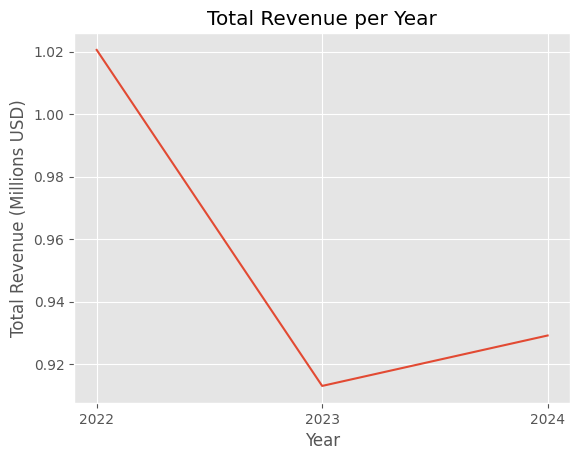

In [73]:
# total_per_year plot

plt.Figure(figsize=(8,5))
plt.plot(total_per_year['year'], total_per_year['revenue_million'])
plt.title('Total Revenue per Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue (Millions USD)');


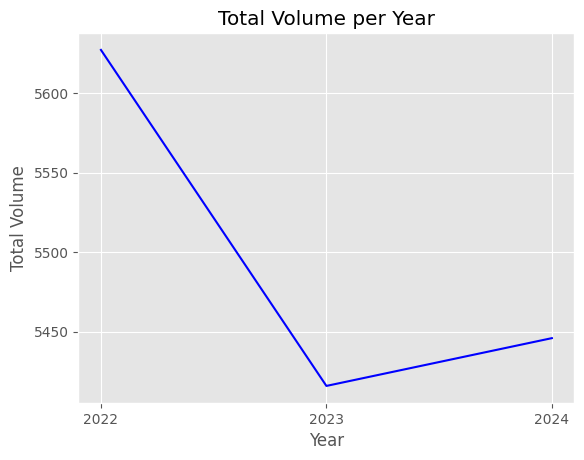

In [74]:
plt.Figure(figsize=(8,5))
plt.plot(total_per_year['year'], total_per_year['total_volume'], color='blue')
plt.title('Total Volume per Year')
plt.xlabel('Year')
plt.ylabel('Total Volume');

###

### Insight

From 2022 to 2023 volume sold decreased by 3.75% and revenue dipped by 10.53%, while between 2023 to 2024 there was a modest increase of 0.55% in volume sold and 1.76% in total revenue. These percetages suggest that volume alone does not fully explain the revenue drop and recovery; other factors such as discount strategies or changes in product mix may also have influenced revenue performance. Though further analysis would be required to confirm this relationship.